In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 8,760h RENEWABLE CANNIBALIZATION & MONTE CARLO PPA VALUATION MODEL
50 MW PV Annual Generation:            75,727.25 MWh
Annual Baseload Spot Price:            €56.11 / MWh
Solar Capture Price (Marktwert Solar): €53.47 / MWh
Solar Capture Rate / Profile Factor:   95.3%
---------------------------------------------------------------------------
10-Year Monte Carlo PPA Pricing (Forward Baseload = €70.00/MWh):
  • P90 Downside Risk PPA Price:       €44.55 / MWh
  • P50 Base Fair PPA Strike Price:    €50.79 / MWh
  • P10 Upside Case PPA Price:         €56.90 / MWh


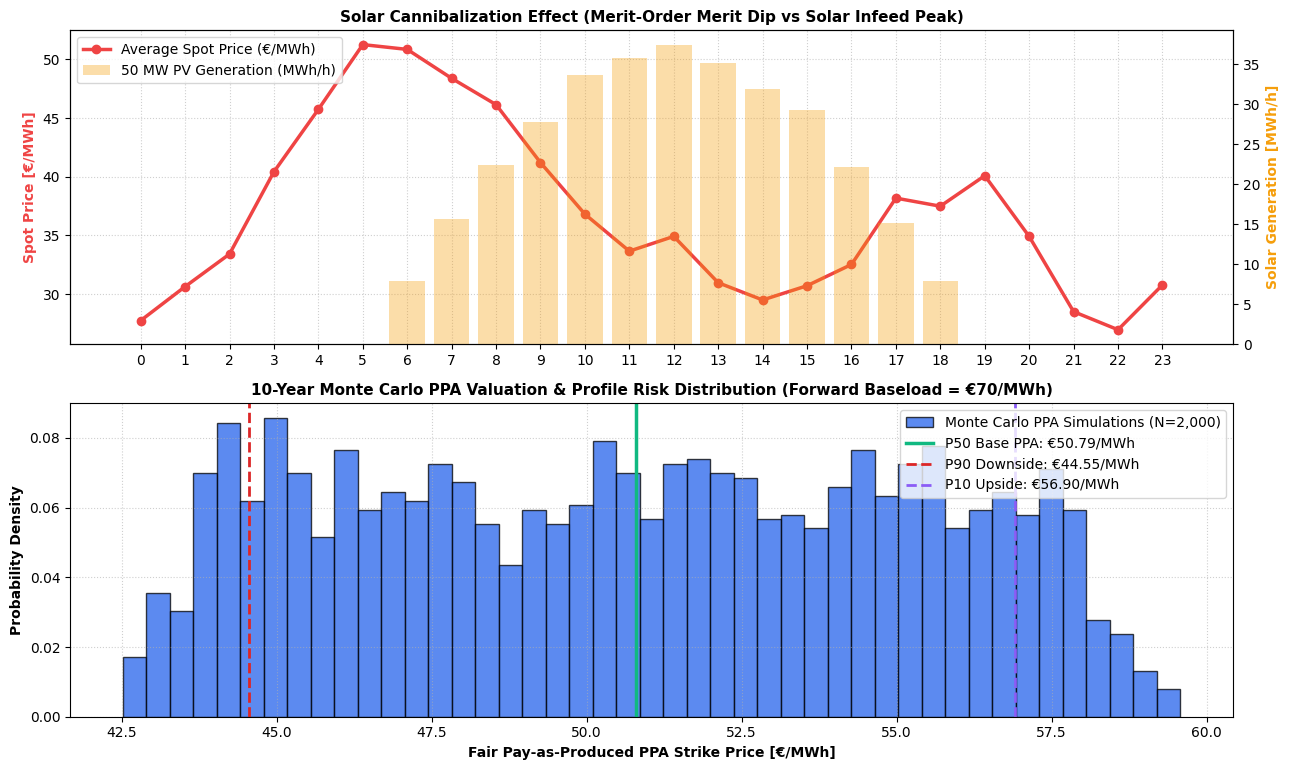

Summary table exported as 'solar_cannibalization_ppa_summary.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# 1. 8,760-HOUR GERMAN WHOLESALE MARKET & SOLAR GENERATION
# ==========================================================
np.random.seed(42)
HOURS = 8760
dates = pd.date_range(start="2026-01-01 00:00:00", periods=HOURS, freq="h")
day_of_year = dates.dayofyear.to_numpy()
hour_of_day = dates.hour.to_numpy()

# Spot Price Base: Seasonality + Hourly Shape
seasonal_base = 65.0 + 15.0 * np.cos(2 * np.pi * (day_of_year - 20) / 365)
daily_shape = 25.0 * np.sin((hour_of_day - 5) * np.pi / 12)

# 50 MW Utility Solar PV Asset Generation (MWh)
solar_declination = np.maximum(
    0, np.sin(np.pi * (hour_of_day - 5) / 14)
) * (0.6 + 0.4 * np.sin(np.pi * (day_of_year - 80) / 185))
solar_declination = np.clip(solar_declination, 0, 1.0)
cloud_noise = np.random.beta(5, 1.5, HOURS)
solar_gen_mwh = np.round(50.0 * solar_declination * cloud_noise, 2)

# Grid-Level Midday Solar Cannibalization Effect
system_solar_gw = (solar_declination * 55.0) * (
    0.8 + 0.2 * np.random.normal(1, 0.1, HOURS)
)
cannibalization_discount = (system_solar_gw / 55.0) ** 1.3 * 48.0

spot_price_eur = (
    seasonal_base
    + daily_shape
    - cannibalization_discount
    + np.random.normal(0, 12, HOURS)
)
spot_price_eur = np.round(np.clip(spot_price_eur, -60.0, 240.0), 2)

df_ppa = pd.DataFrame({
    'timestamp': dates,
    'day_of_year': day_of_year,
    'hour': hour_of_day,
    'spot_price_eur_mwh': spot_price_eur,
    'solar_gen_mwh': solar_gen_mwh,
})

# ==========================================================
# 2. ANNUAL BENCHMARK: CAPTURE PRICE & PROFILE FACTOR
# ==========================================================
total_annual_gen_mwh = df_ppa['solar_gen_mwh'].sum()
baseload_price_eur = df_ppa['spot_price_eur_mwh'].mean()

# Marktwert Solar: Volume-Weighted Average Capture Price
solar_capture_price_eur = (
    df_ppa['solar_gen_mwh'] * df_ppa['spot_price_eur_mwh']
).sum() / total_annual_gen_mwh
solar_capture_rate_pct = (solar_capture_price_eur / baseload_price_eur) * 100.0

# ==========================================================
# 3. 10-YEAR MONTE CARLO PPA PRICING & RISK DISCOUNT ENGINE
# ==========================================================
N_SIMS = 2000
FORWARD_BASELOAD = 70.00  # 10-Year Forward Baseload Reference (€/MWh)
mc_ppa_prices = []

for _ in range(N_SIMS):
  sim_capture_rate = np.random.uniform(0.65, 0.88)
  shape_volume_risk_discount = np.random.uniform(0.03, 0.07)
  fair_ppa = (
      FORWARD_BASELOAD * sim_capture_rate * (1 - shape_volume_risk_discount)
  )
  mc_ppa_prices.append(fair_ppa)

mc_ppa_prices = np.array(mc_ppa_prices)
p10_ppa = np.percentile(mc_ppa_prices, 10)  # Downside Risk Value
p50_ppa = np.percentile(mc_ppa_prices, 50)  # Base Fair Value
p90_ppa = np.percentile(mc_ppa_prices, 90)  # Upside Value

print('=' * 75)
print(' 8,760h RENEWABLE CANNIBALIZATION & MONTE CARLO PPA VALUATION MODEL')
print('=' * 75)
print(f'50 MW PV Annual Generation:            {total_annual_gen_mwh:,.2f} MWh')
print(f'Annual Baseload Spot Price:            €{baseload_price_eur:.2f} / MWh')
print(
    'Solar Capture Price (Marktwert Solar):'
    f' €{solar_capture_price_eur:.2f} / MWh'
)
print(f'Solar Capture Rate / Profile Factor:   {solar_capture_rate_pct:.1f}%')
print('-' * 75)
print(
    '10-Year Monte Carlo PPA Pricing (Forward Baseload ='
    f' €{FORWARD_BASELOAD:.2f}/MWh):'
)
print(f'  • P90 Downside Risk PPA Price:       €{p10_ppa:.2f} / MWh')
print(f'  • P50 Base Fair PPA Strike Price:    €{p50_ppa:.2f} / MWh')
print(f'  • P10 Upside Case PPA Price:         €{p90_ppa:.2f} / MWh')
print('=' * 75)

# ==========================================================
# 4. VISUALIZATION & ARTIFACT EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.8))

# Plot 1: Average Summer Diurnal Duck Curve
summer_df = df_ppa[
    (df_ppa['day_of_year'] >= 150) & (df_ppa['day_of_year'] <= 240)
]
diurnal = (
    summer_df.groupby('hour')
    .agg({'spot_price_eur_mwh': 'mean', 'solar_gen_mwh': 'mean'})
    .reset_index()
)

ax1.plot(
    diurnal['hour'],
    diurnal['spot_price_eur_mwh'],
    color='#EF4444',
    lw=2.5,
    marker='o',
    label='Average Spot Price (€/MWh)',
)
ax1.set_ylabel('Spot Price [€/MWh]', color='#EF4444', fontweight='bold')
ax1.set_title(
    'Solar Cannibalization Effect (Merit-Order Merit Dip vs Solar Infeed Peak)',
    fontweight='bold',
    fontsize=11,
)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle=':', alpha=0.6)

ax1_twin = ax1.twinx()
ax1_twin.bar(
    diurnal['hour'],
    diurnal['solar_gen_mwh'],
    color='#F59E0B',
    alpha=0.35,
    label='50 MW PV Generation (MWh/h)',
)
ax1_twin.set_ylabel(
    'Solar Generation [MWh/h]', color='#F59E0B', fontweight='bold'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Plot 2: Monte Carlo PPA Price Distribution
ax2.hist(
    mc_ppa_prices,
    bins=45,
    color='#2563EB',
    alpha=0.75,
    edgecolor='black',
    density=True,
    label='Monte Carlo PPA Simulations (N=2,000)',
)
ax2.axvline(
    p50_ppa,
    color='#10B981',
    lw=2.5,
    linestyle='-',
    label=f'P50 Base PPA: €{p50_ppa:.2f}/MWh',
)
ax2.axvline(
    p10_ppa,
    color='#DC2626',
    lw=2.0,
    linestyle='--',
    label=f'P90 Downside: €{p10_ppa:.2f}/MWh',
)
ax2.axvline(
    p90_ppa,
    color='#8B5CF6',
    lw=2.0,
    linestyle='--',
    label=f'P10 Upside: €{p90_ppa:.2f}/MWh',
)
ax2.set_xlabel(
    'Fair Pay-as-Produced PPA Strike Price [€/MWh]', fontweight='bold'
)
ax2.set_ylabel('Probability Density', fontweight='bold')
ax2.set_title(
    '10-Year Monte Carlo PPA Valuation & Profile Risk Distribution (Forward'
    ' Baseload = €70/MWh)',
    fontweight='bold',
    fontsize=11,
)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('solar_cannibalization_ppa_valuation_model.png', dpi=300)
plt.show()

# Export Summary Data
df_summary = pd.DataFrame({
    'Metric': [
        'Annual Generation (MWh)',
        'Average Baseload Price (€/MWh)',
        'Solar Capture Price Marktwert (€/MWh)',
        'Solar Capture Rate (%)',
        'P50 Fair PPA Strike Price (€/MWh)',
        'P90 Downside Risk PPA Price (€/MWh)',
    ],
    'Value': [
        f'{total_annual_gen_mwh:,.2f}',
        f'{baseload_price_eur:.2f}',
        f'{solar_capture_price_eur:.2f}',
        f'{solar_capture_rate_pct:.1f}%',
        f'{p50_ppa:.2f}',
        f'{p10_ppa:.2f}',
    ],
})
df_summary.to_csv('solar_cannibalization_ppa_summary.csv', index=False)
print("Summary table exported as 'solar_cannibalization_ppa_summary.csv'")